# CP1. Baseline-модели и первые эксперименты

В этом ноутбуке обучаются первые модели для задачи предсказания удовлетворённости пассажира.

Данные уже подготовлены в `EDA_01.ipynb` и сохранены в `data/processed/`.

Основная цель этого этапа - получить воспроизводимый baseline, сравнить несколько моделей и зафиксировать первые результаты в таблице экспериментов.

## Метрики качества

Задача является бинарной классификацией, поэтому основной метрикой выбрана ROC-AUC. Она оценивает, насколько хорошо модель ранжирует объекты по вероятности принадлежности к положительному классу `satisfied`.

Дополнительно считаются Accuracy, Precision, Recall и F1-score.

В качестве основной метрики для сравнения моделей используется ROC-AUC. F1-score анализируется дополнительно, так как он учитывает баланс между Precision и Recall.

## Загрузка подготовленных выборок

Используются train, validation и test, сохранённые после EDA. На этом этапе модели обучаются на train и сравниваются на validation. Test-выборка пока не используется для выбора модели, чтобы оставить её для финальной оценки.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import (
    ExtraTreesClassifier,
    GradientBoostingClassifier,
    RandomForestClassifier,
)
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier

RANDOM_STATE = 506

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

PROCESSED_DATA_DIR = PROJECT_ROOT / "data" / "processed"
REPORT_IMAGES_DIR = PROJECT_ROOT / "report" / "images"
REPORT_TABLES_DIR = PROJECT_ROOT / "report" / "tables"

REPORT_IMAGES_DIR.mkdir(parents=True, exist_ok=True)
REPORT_TABLES_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", 100)

In [2]:
train_data = pd.read_csv(PROCESSED_DATA_DIR / "train.csv")
val_data = pd.read_csv(PROCESSED_DATA_DIR / "val.csv")
test_data = pd.read_csv(PROCESSED_DATA_DIR / "test.csv")

print("Train:", train_data.shape)
print("Validation:", val_data.shape)
print("Test:", test_data.shape)

train_data.head()

Train: (90916, 26)
Validation: (19482, 26)
Test: (19482, 26)


,customer_type,age,type_of_travel,class,flight_distance,seat_comfort,departure_arrival_time_convenient,food_and_drink,gate_location,inflight_wifi_service,inflight_entertainment,online_support,ease_of_online_booking,on_board_service,leg_room_service,baggage_handling,checkin_service,cleanliness,online_boarding,departure_delay_in_minutes,arrival_delay_in_minutes,total_delay,has_delay,is_long_flight,mean_service_score,target
0,Loyal Customer,48,Business travel,Business,2267,5,5,5,5,4,5,4,4,4,4,4,5,4,5,0,1.0,1.0,1,1,4.500000,1
1,Loyal Customer,47,Business travel,Business,2011,3,3,3,3,4,5,5,5,5,5,5,3,5,3,0,0.0,0.0,0,1,4.071429,1
2,Loyal Customer,7,Personal Travel,Eco Plus,2227,5,5,5,3,4,5,4,4,3,3,5,5,4,4,0,0.0,0.0,0,1,4.214286,1
3,disloyal Customer,46,Business travel,Eco,2233,1,1,1,3,3,1,3,3,1,1,2,2,3,3,0,0.0,0.0,0,1,2.000000,0
4,Loyal Customer,52,Business travel,Business,2881,5,4,5,5,5,5,5,4,4,5,4,5,4,3,1,1.0,2.0,1,1,4.500000,1


In [3]:
target_column = "target"

X_train = train_data.drop(columns=[target_column])
y_train = train_data[target_column]

X_val = val_data.drop(columns=[target_column])
y_val = val_data[target_column]

X_test = test_data.drop(columns=[target_column])
y_test = test_data[target_column]

print(X_train.shape, y_train.shape)
print(X_val.shape, y_val.shape)
print(X_test.shape, y_test.shape)

(90916, 25) (90916,)
(19482, 25) (19482,)
(19482, 25) (19482,)


## Наборы признаков

Для baseline без feature engineering используется набор исходных признаков: из данных удаляются признаки, созданные в EDA.

Для остальных экспериментов используется полный набор признаков, включая `total_delay`, `has_delay`, `is_long_flight` и `mean_service_score`.

In [4]:
engineered_features = [
    "total_delay",
    "has_delay",
    "is_long_flight",
    "mean_service_score",
]

base_features = [
    column for column in X_train.columns if column not in engineered_features
]

X_train_base = X_train[base_features]
X_val_base = X_val[base_features]

print("Base feature count:", len(base_features))
print("Full feature count:", X_train.shape[1])

Base feature count: 21
Full feature count: 25


## Preprocessing pipeline

Для числовых признаков используется заполнение пропусков медианой и стандартизация.

Для категориальных признаков используется заполнение наиболее частым значением и OneHotEncoding.

Все преобразования находятся внутри `sklearn Pipeline`, поэтому обучаются только на train-части.

In [5]:
def make_one_hot_encoder():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)


def build_preprocessor(features: pd.DataFrame) -> ColumnTransformer:
    numeric_features = features.select_dtypes(include=["number"]).columns.tolist()
    categorical_features = features.select_dtypes(exclude=["number"]).columns.tolist()

    numeric_transformer = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]
    )

    categorical_transformer = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", make_one_hot_encoder()),
        ]
    )

    return ColumnTransformer(
        transformers=[
            ("numeric", numeric_transformer, numeric_features),
            ("categorical", categorical_transformer, categorical_features),
        ],
        remainder="drop",
    )

## Функция оценки моделей

Все модели сравниваются на validation-выборке по одному набору метрик.

In [6]:
def evaluate_model(
    experiment_name: str,
    model_name: str,
    model,
    X_train_part: pd.DataFrame,
    y_train_part: pd.Series,
    X_val_part: pd.DataFrame,
    y_val_part: pd.Series,
    feature_set: str,
    params: str,
) -> dict:
    pipeline = Pipeline(
        steps=[
            ("preprocessor", build_preprocessor(X_train_part)),
            ("model", model),
        ]
    )

    pipeline.fit(X_train_part, y_train_part)

    y_pred = pipeline.predict(X_val_part)

    if hasattr(pipeline, "predict_proba"):
        y_score = pipeline.predict_proba(X_val_part)[:, 1]
    else:
        y_score = y_pred

    return {
        "experiment_name": experiment_name,
        "model": model_name,
        "feature_set": feature_set,
        "params": params,
        "accuracy": accuracy_score(y_val_part, y_pred),
        "precision": precision_score(y_val_part, y_pred, zero_division=0),
        "recall": recall_score(y_val_part, y_pred, zero_division=0),
        "f1": f1_score(y_val_part, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_val_part, y_score),
    }

## Baseline без feature engineering

В качестве нижней границы качества используется `DummyClassifier`. Также обучается простая `LogisticRegression` на исходных признаках без feature engineering.

In [7]:
results = []

baseline_experiments = [
    (
        "dummy_without_feature_engineering",
        "dummy_most_frequent",
        DummyClassifier(strategy="most_frequent"),
        "strategy=most_frequent",
    ),
    (
        "logreg_without_feature_engineering",
        "logistic_regression",
        LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
        "max_iter=1000",
    ),
]

for experiment_name, model_name, model, params in baseline_experiments:
    result = evaluate_model(
        experiment_name=experiment_name,
        model_name=model_name,
        model=model,
        X_train_part=X_train_base,
        y_train_part=y_train,
        X_val_part=X_val_base,
        y_val_part=y_val,
        feature_set="without_feature_engineering",
        params=params,
    )
    results.append(result)

pd.DataFrame(results)

,experiment_name,model,feature_set,params,accuracy,precision,recall,f1,roc_auc
0,dummy_without_feature_engineering,dummy_most_frequent,without_feature_engineering,strategy=most_frequent,0.547326,0.547326,1.000000,0.707447,0.500000
1,logreg_without_feature_engineering,logistic_regression,without_feature_engineering,max_iter=1000,0.829843,0.845496,0.843196,0.844344,0.901611


## Эксперименты с несколькими моделями

Далее сравниваются классические модели и ансамбли на полном наборе признаков. В таблицу включены разные модели и несколько вариантов гиперпараметров для деревьев и ансамблей.

In [8]:
model_experiments = [
    (
        "logreg_with_feature_engineering",
        "logistic_regression",
        LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
        "max_iter=1000",
    ),
    (
        "decision_tree_depth_6",
        "decision_tree",
        DecisionTreeClassifier(max_depth=6, random_state=RANDOM_STATE),
        "max_depth=6",
    ),
    (
        "decision_tree_depth_10",
        "decision_tree",
        DecisionTreeClassifier(max_depth=10, random_state=RANDOM_STATE),
        "max_depth=10",
    ),
    (
        "random_forest_depth_10",
        "random_forest",
        RandomForestClassifier(
            n_estimators=150,
            max_depth=10,
            random_state=RANDOM_STATE,
            n_jobs=-1,
        ),
        "n_estimators=150, max_depth=10",
    ),
    (
        "random_forest_depth_14",
        "random_forest",
        RandomForestClassifier(
            n_estimators=200,
            max_depth=14,
            random_state=RANDOM_STATE,
            n_jobs=-1,
        ),
        "n_estimators=200, max_depth=14",
    ),
    (
        "extra_trees_depth_14",
        "extra_trees",
        ExtraTreesClassifier(
            n_estimators=200,
            max_depth=14,
            random_state=RANDOM_STATE,
            n_jobs=-1,
        ),
        "n_estimators=200, max_depth=14",
    ),
    (
        "gradient_boosting_default",
        "gradient_boosting",
        GradientBoostingClassifier(random_state=RANDOM_STATE),
        "default",
    ),
]

for experiment_name, model_name, model, params in model_experiments:
    result = evaluate_model(
        experiment_name=experiment_name,
        model_name=model_name,
        model=model,
        X_train_part=X_train,
        y_train_part=y_train,
        X_val_part=X_val,
        y_val_part=y_val,
        feature_set="with_feature_engineering",
        params=params,
    )
    results.append(result)

results_df = pd.DataFrame(results).sort_values("roc_auc", ascending=False)
results_df

,experiment_name,model,feature_set,params,accuracy,precision,recall,f1,roc_auc
6,random_forest_depth_14,random_forest,with_feature_engineering,"n_estimators=200, max_depth=14",0.944924,0.954072,0.944856,0.949442,0.989989
7,extra_trees_depth_14,extra_trees,with_feature_engineering,"n_estimators=200, max_depth=14",0.936711,0.942973,0.941292,0.942132,0.987124
5,random_forest_depth_10,random_forest,with_feature_engineering,"n_estimators=150, max_depth=10",0.927164,0.930114,0.937353,0.933719,0.983912
8,gradient_boosting_default,gradient_boosting,with_feature_engineering,default,0.919259,0.927966,0.924224,0.926091,0.978345
4,decision_tree_depth_10,decision_tree,with_feature_engineering,max_depth=10,0.922595,0.925379,0.933884,0.929612,0.976269
3,decision_tree_depth_6,decision_tree,with_feature_engineering,max_depth=6,0.893183,0.909525,0.893745,0.901566,0.957550
2,logreg_with_feature_engineering,logistic_regression,with_feature_engineering,max_iter=1000,0.830972,0.846726,0.843946,0.845334,0.902204
1,logreg_without_feature_engineering,logistic_regression,without_feature_engineering,max_iter=1000,0.829843,0.845496,0.843196,0.844344,0.901611
0,dummy_without_feature_engineering,dummy_most_frequent,without_feature_engineering,strategy=most_frequent,0.547326,0.547326,1.000000,0.707447,0.500000


In [9]:
results_df.to_csv(REPORT_TABLES_DIR / "cp1_model_results.csv", index=False)

## Сравнение моделей

Для быстрого сравнения построен график ROC-AUC на validation-выборке.

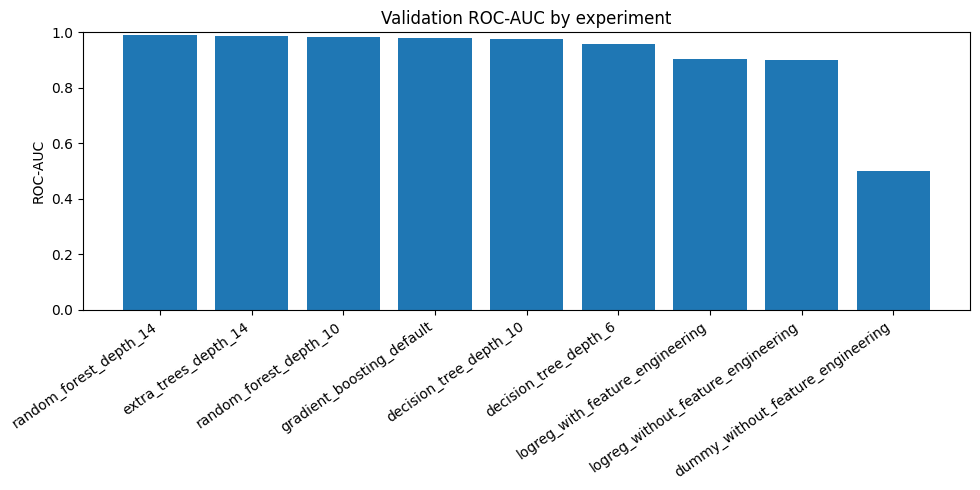

In [10]:
plt.figure(figsize=(10, 5))
plt.bar(results_df["experiment_name"], results_df["roc_auc"])
plt.title("Validation ROC-AUC by experiment")
plt.ylabel("ROC-AUC")
plt.xticks(rotation=35, ha="right")
plt.ylim(0, 1)
plt.tight_layout()
plt.savefig(REPORT_IMAGES_DIR / "cp1_model_roc_auc.png", dpi=200)
plt.show()

In [11]:
best_model = results_df.iloc[0]
best_model

experiment_name            random_forest_depth_14
model                               random_forest
feature_set              with_feature_engineering
params             n_estimators=200, max_depth=14
accuracy                                 0.944924
precision                                0.954072
recall                                   0.944856
f1                                       0.949442
roc_auc                                  0.989989
Name: 6, dtype: object

## Выводы по моделированию

На этом этапе получен baseline и проведены первые эксперименты с несколькими моделями.

`DummyClassifier` задаёт нижнюю границу качества. На нем ROC-AUC = 0.500, что соответствует случайному значению.

`LogisticRegression` без feature engineering используется как простой baseline на исходных признаках. Она уже заметно лучше dummy baseline и даёт ROC-AUC около 0.902.

После добавления feature engineering были обучены несколько моделей: LogisticRegression, DecisionTree, RandomForest, ExtraTrees и GradientBoosting. Ансамблевые модели показали лучшие результаты, что говорит о наличии нелинейных зависимостей и взаимодействий между признаками.

Лучший результат на validation-выборке показала модель `RandomForestClassifier` с параметрами `n_estimators=200`, `max_depth=14`:

- ROC-AUC: 0.989989;
- F1-score: 0.949442;
- Accuracy: 0.944924;
- Precision: 0.954072;
- Recall: 0.944856.

На момент CP1 эта модель считается лучшей по основной метрике ROC-AUC.